# Import Libraries


In [23]:
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time

# PART A:

## 1.Create Arrays

In [24]:
def create_arrays():
    # 1D arrays
    arr_from_list = np.array([1, 2, 3, 4, 5])
    arr_arange = np.arange(0, 10, 2)          # step-based
    arr_linspace = np.linspace(0, 1, 5)       # evenly spaced floats

    # Multi-dimensional arrays
    arr_2d = np.array([[1, 2, 3], [4, 5, 6]])
    arr_zeros = np.zeros((2, 3))
    arr_ones = np.ones((3, 3))
    arr_identity = np.eye(3)
    arr_random = np.random.randint(1, 10, (2, 4))
    arr_full = np.full((2, 2), 7)

    print("---------------------------------")
    print("1D from list:", arr_from_list)
    print("---------------------------------")
    print("arange:", arr_arange)
    print("---------------------------------")
    print("linspace:", arr_linspace)
    print("---------------------------------")
    print("2D array:\n", arr_2d)
    print("---------------------------------")
    print("Zeros:\n", arr_zeros)
    print("---------------------------------")
    print("Ones:\n", arr_ones)
    print("---------------------------------")
    print("Identity:\n", arr_identity)
    print("---------------------------------")
    print("Random ints:\n", arr_random)
    print("---------------------------------")
    print("Full:\n", arr_full)
    print("---------------------------------")

create_arrays()

---------------------------------
1D from list: [1 2 3 4 5]
---------------------------------
arange: [0 2 4 6 8]
---------------------------------
linspace: [0.   0.25 0.5  0.75 1.  ]
---------------------------------
2D array:
 [[1 2 3]
 [4 5 6]]
---------------------------------
Zeros:
 [[0. 0. 0.]
 [0. 0. 0.]]
---------------------------------
Ones:
 [[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]
---------------------------------
Identity:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
---------------------------------
Random ints:
 [[1 2 3 4]
 [6 5 5 6]]
---------------------------------
Full:
 [[7 7]
 [7 7]]
---------------------------------


## 2. Indexing, Slicing, Reshaping, Math Operations

In [25]:
def indexing_slicing_reshaping():
    arr = np.array([[10, 20, 30, 40],
                     [50, 60, 70, 80],
                     [90, 100, 110, 120]])
    print("---------------------------------")
    print("Original array:\n", arr)

    # Indexing
    print("---------------------------------")
    print("Element at [1,2]:", arr[1, 2])

    # Slicing
    print("---------------------------------")
    print("First two rows, cols 1-3:\n", arr[:2, 1:3])
    print("---------------------------------")
    print("Last two rows, all columns:\n", arr[-2:, :])
    print("---------------------------------")
    print("Every other column:\n", arr[:, ::2])

    # Reshaping
    print("---------------------------------")
    reshaped = arr.reshape(4, 3)
    print("Reshaped (4x3):\n", reshaped)
    print("---------------------------------")
    flattened = arr.flatten()
    print("Flattened:", flattened)

    # Mathematical operations
    print("---------------------------------")
    print("Sum:", arr.sum())
    print("---------------------------------")
    print("Mean:", arr.mean())
    print("---------------------------------")
    print("Max per column:", arr.max(axis=0))
    print("---------------------------------")
    print("Min per row:", arr.min(axis=1))
    print("---------------------------------")
    print("Element-wise square:\n", arr ** 2)
    print("---------------------------------------------------")
    print("Square root:\n", np.sqrt(arr))
    print("---------------------------------------------------")

indexing_slicing_reshaping()

---------------------------------
Original array:
 [[ 10  20  30  40]
 [ 50  60  70  80]
 [ 90 100 110 120]]
---------------------------------
Element at [1,2]: 70
---------------------------------
First two rows, cols 1-3:
 [[20 30]
 [60 70]]
---------------------------------
Last two rows, all columns:
 [[ 50  60  70  80]
 [ 90 100 110 120]]
---------------------------------
Every other column:
 [[ 10  30]
 [ 50  70]
 [ 90 110]]
---------------------------------
Reshaped (4x3):
 [[ 10  20  30]
 [ 40  50  60]
 [ 70  80  90]
 [100 110 120]]
---------------------------------
Flattened: [ 10  20  30  40  50  60  70  80  90 100 110 120]
---------------------------------
Sum: 780
---------------------------------
Mean: 65.0
---------------------------------
Max per column: [ 90 100 110 120]
---------------------------------
Min per row: [10 50 90]
---------------------------------
Element-wise square:
 [[  100   400   900  1600]
 [ 2500  3600  4900  6400]
 [ 8100 10000 12100 14400]]
------

## 3. Broadcasting

In [26]:
def broadcasting_demo():
    # Example 1: scalar with array
    arr = np.array([1, 2, 3, 4])
    print("Array + scalar:", arr + 10)
    print("---------------------------------")

    # Example 2: 1D array broadcast across 2D array
    matrix = np.array([[1, 2, 3],
                        [4, 5, 6],
                        [7, 8, 9]])
    row_vector = np.array([10, 20, 30])
    print("Matrix + row vector (broadcast):\n", matrix + row_vector)
    print("---------------------------------")

    # Example 3: column vector broadcasting
    col_vector = np.array([[100], [200], [300]])
    print("Matrix + column vector (broadcast):\n", matrix + col_vector)
    print("---------------------------------")

    # Example 4: practical use — normalizing data
    data = np.array([[1, 2], [3, 4], [5, 6]], dtype=float)
    mean = data.mean(axis=0)
    std = data.std(axis=0)
    normalized = (data - mean) / std
    print("Normalized data:\n", normalized)
    print("---------------------------------")

broadcasting_demo()

Array + scalar: [11 12 13 14]
---------------------------------
Matrix + row vector (broadcast):
 [[11 22 33]
 [14 25 36]
 [17 28 39]]
---------------------------------
Matrix + column vector (broadcast):
 [[101 102 103]
 [204 205 206]
 [307 308 309]]
---------------------------------
Normalized data:
 [[-1.22474487 -1.22474487]
 [ 0.          0.        ]
 [ 1.22474487  1.22474487]]
---------------------------------


## 4. Vectorized Operation vs Loop

In [27]:
def vectorized_vs_loop(n=1_000_000):
    a = list(range(n))
    b = list(range(n))

    # Traditional loop
    start = time.time()
    for i in range(n):
      result_loop = a[i] + b[i]
    loop_time = time.time() - start

    # Vectorized (NumPy)
    arr_a = np.arange(n)
    arr_b = np.arange(n)
    start = time.time()
    result_vec = arr_a + arr_b
    vec_time = time.time() - start

    print(f"Loop time: {loop_time:.5f} seconds")
    print("--------------------------------------------")
    print(f"Vectorized time: {vec_time:.5f} seconds")
    print("--------------------------------------------")
    print(f"Vectorized is ~{loop_time/vec_time:.1f}x faster")
    print("--------------------------------------------")

vectorized_vs_loop()

Loop time: 0.06494 seconds
--------------------------------------------
Vectorized time: 0.00597 seconds
--------------------------------------------
Vectorized is ~10.9x faster
--------------------------------------------


## 5. Linear Algebra Operations

In [28]:
def linear_algebra_ops():
    A = np.array([[1, 2], [3, 4]])
    B = np.array([[5, 6], [7, 8]])
    v1 = np.array([1, 2, 3])
    v2 = np.array([4, 5, 6])

    # Dot product (vectors)
    print("Dot product (vectors):", np.dot(v1, v2))
    print("--------------------------------------------")
    # Matrix multiplication
    print("Matrix multiplication (A @ B):\n", A @ B)
    print("--------------------------------------------")
    print("Matrix multiplication (np.dot):\n", np.dot(A, B))
    print("--------------------------------------------")
    print("Matrix multiplication (np.matmul):\n", np.matmul(A, B))
    print("--------------------------------------------")

    # Transpose
    print("Transpose of A:\n", A.T)
    print("--------------------------------------------")

    # Determinant
    print("Determinant of A:", np.linalg.det(A))
    print("--------------------------------------------")

    # Inverse (only if determinant is non-zero)
    det = np.linalg.det(A)
    if det != 0:
        print("Inverse of A:\n", np.linalg.inv(A))
    else:
        print("A is singular; inverse does not exist.")

    # Solving a system of linear equations: Ax = b
    b = np.array([5, 6])
    x = np.linalg.solve(A, b)
    print("Solution to Ax = b:", x)
    print("--------------------------------------------")

    # Eigenvalues and eigenvectors (bonus)
    eigvals, eigvecs = np.linalg.eig(A)
    print("Eigenvalues:", eigvals)
    print("--------------------------------------------")
    print("Eigenvectors:\n", eigvecs)
    print("--------------------------------------------")

linear_algebra_ops()

Dot product (vectors): 32
--------------------------------------------
Matrix multiplication (A @ B):
 [[19 22]
 [43 50]]
--------------------------------------------
Matrix multiplication (np.dot):
 [[19 22]
 [43 50]]
--------------------------------------------
Matrix multiplication (np.matmul):
 [[19 22]
 [43 50]]
--------------------------------------------
Transpose of A:
 [[1 3]
 [2 4]]
--------------------------------------------
Determinant of A: -2.0000000000000004
--------------------------------------------
Inverse of A:
 [[-2.   1. ]
 [ 1.5 -0.5]]
Solution to Ax = b: [-4.   4.5]
--------------------------------------------
Eigenvalues: [-0.37228132  5.37228132]
--------------------------------------------
Eigenvectors:
 [[-0.82456484 -0.41597356]
 [ 0.56576746 -0.90937671]]
--------------------------------------------


# PART B
## 1. Creating and Manipulating Seriess and Dataframes

In [29]:
def series_and_dataframes():
    # Series from a list
    s1 = pd.Series([10, 20, 30, 40], name="Numbers")
    print("Series from list:\n", s1)
    print("----------------------------------------------------")


    # Series with custom index
    s2 = pd.Series([1, 2, 3], index=["a", "b", "c"])
    print("Series with custom index:\n", s2)
    print("----------------------------------------------------")

    # Series from a dictionary
    s3 = pd.Series({"Math": 85, "Science": 90, "English": 78})
    print("Series from dict:\n", s3)
    print("----------------------------------------------------")


    # DataFrame from a dictionary of lists
    data = {
        "Name": ["Ali", "Sara", "John", "Ayesha", "Bilal"],
        "Age": [23, 21, 25, 22, 24],
        "Department": ["CS", "SE", "CS", "AI", "SE"],
        "Marks": [85, 78, 92, 88, 76]
    }
    df = pd.DataFrame(data)
    print("DataFrame:\n", df)
    print("----------------------------------------------------")


    # Manipulating: adding a new column
    df["Grade"] = np.where(df["Marks"] >= 85, "A", "B")
    print("With new column:\n", df)
    print("----------------------------------------------------")


    # Manipulating: updating a value
    df.loc[0, "Age"] = 24
    print("After update:\n", df)
    print("----------------------------------------------------")


    # Dropping a column
    df_dropped = df.drop(columns=["Grade"])
    print("After dropping Grade column:\n", df_dropped)
    print("----------------------------------------------------")

    return df

series_and_dataframes()

Series from list:
 0    10
1    20
2    30
3    40
Name: Numbers, dtype: int64
----------------------------------------------------
Series with custom index:
 a    1
b    2
c    3
dtype: int64
----------------------------------------------------
Series from dict:
 Math       85
Science    90
English    78
dtype: int64
----------------------------------------------------
DataFrame:
      Name  Age Department  Marks
0     Ali   23         CS     85
1    Sara   21         SE     78
2    John   25         CS     92
3  Ayesha   22         AI     88
4   Bilal   24         SE     76
----------------------------------------------------
With new column:
      Name  Age Department  Marks Grade
0     Ali   23         CS     85     A
1    Sara   21         SE     78     B
2    John   25         CS     92     A
3  Ayesha   22         AI     88     A
4   Bilal   24         SE     76     B
----------------------------------------------------
After update:
      Name  Age Department  Marks Grade
0    

,Name,Age,Department,Marks,Grade
0,Ali,24,CS,85,A
1,Sara,21,SE,78,B
2,John,25,CS,92,A
3,Ayesha,22,AI,88,A
4,Bilal,24,SE,76,B


## 2. Indexing, filtering, sorting, selection

In [30]:
def indexing_filtering_sorting():
    data = {
        "Name": ["Ali", "Sara", "John", "Ayesha", "Bilal"],
        "Age": [23, 21, 25, 22, 24],
        "Department": ["CS", "SE", "CS", "AI", "SE"],
        "Marks": [85, 78, 92, 88, 76]
    }
    df = pd.DataFrame(data)

    # Indexing with loc and iloc
    print("Row at label 2 (loc):\n", df.loc[2])
    print("-------------------------------------------------")
    print("Row at position 2 (iloc):\n", df.iloc[2])
    print("-------------------------------------------------")
    print("Specific cell (loc):", df.loc[1, "Name"])
    print("-------------------------------------------------")
    print("Slice of rows/cols (iloc):\n", df.iloc[0:3, 0:2])
    print("-------------------------------------------------")

    # Selection
    print("Single column:\n", df["Name"])
    print("-------------------------------------------------")
    print("Multiple columns:\n", df[["Name", "Marks"]])
    print("-------------------------------------------------")

    # Filtering
    high_scorers = df[df["Marks"] > 80]
    print("Students with Marks > 80:\n", high_scorers)
    print("-------------------------------------------------")

    cs_dept = df[(df["Department"] == "CS") & (df["Marks"] >= 85)]
    print("CS department with Marks >= 85:\n", cs_dept)
    print("-------------------------------------------------")

    # Sorting
    sorted_by_marks = df.sort_values(by="Marks", ascending=False)
    print("Sorted by Marks (desc):\n", sorted_by_marks)
    print("-------------------------------------------------")

    sorted_multi = df.sort_values(by=["Department", "Marks"], ascending=[True, False])
    print("Sorted by Department then Marks:\n", sorted_multi)
    print("-------------------------------------------------")

indexing_filtering_sorting()

Row at label 2 (loc):
 Name          John
Age             25
Department      CS
Marks           92
Name: 2, dtype: object
-------------------------------------------------
Row at position 2 (iloc):
 Name          John
Age             25
Department      CS
Marks           92
Name: 2, dtype: object
-------------------------------------------------
Specific cell (loc): Sara
-------------------------------------------------
Slice of rows/cols (iloc):
    Name  Age
0   Ali   23
1  Sara   21
2  John   25
-------------------------------------------------
Single column:
 0       Ali
1      Sara
2      John
3    Ayesha
4     Bilal
Name: Name, dtype: object
-------------------------------------------------
Multiple columns:
      Name  Marks
0     Ali     85
1    Sara     78
2    John     92
3  Ayesha     88
4   Bilal     76
-------------------------------------------------
Students with Marks > 80:
      Name  Age Department  Marks
0     Ali   23         CS     85
2    John   25         CS     

## 3. Groupby Operations

In [31]:
def groupby_operations():
    data = {
        "Name": ["Ali", "Sara", "John", "Ayesha", "Bilal", "Zara"],
        "Department": ["CS", "SE", "CS", "AI", "SE", "AI"],
        "Marks": [85, 78, 92, 88, 76, 95],
        "Age": [23, 21, 25, 22, 24, 20]
    }
    df = pd.DataFrame(data)

    # Group by single column, single aggregation
    dept_avg = df.groupby("Department")["Marks"].mean()
    print("Average Marks per Department:\n", dept_avg)
    print("-------------------------------------------------")

    # Group by with multiple aggregations
    dept_summary = df.groupby("Department").agg(
        Avg_Marks=("Marks", "mean"),
        Max_Marks=("Marks", "max"),
        Min_Marks=("Marks", "min"),
        Count=("Name", "count")
    )
    print("Department summary:\n", dept_summary)
    print("-------------------------------------------------")

    # Group by with multiple columns
    grouped_multi = df.groupby("Department")[["Marks", "Age"]].mean()
    print("Mean Marks and Age per Department:\n", grouped_multi)
    print("-------------------------------------------------")

    # Sorting group results
    print("Departments sorted by average Marks:\n", dept_avg.sort_values(ascending=False))
    print("-------------------------------------------------")

groupby_operations()

Average Marks per Department:
 Department
AI    91.5
CS    88.5
SE    77.0
Name: Marks, dtype: float64
-------------------------------------------------
Department summary:
             Avg_Marks  Max_Marks  Min_Marks  Count
Department                                        
AI               91.5         95         88      2
CS               88.5         92         85      2
SE               77.0         78         76      2
-------------------------------------------------
Mean Marks and Age per Department:
             Marks   Age
Department             
AI           91.5  21.0
CS           88.5  24.0
SE           77.0  22.5
-------------------------------------------------
Departments sorted by average Marks:
 Department
AI    91.5
CS    88.5
SE    77.0
Name: Marks, dtype: float64
-------------------------------------------------


## 4. Merging and Joining Dataframes

In [32]:
def merge_and_join():
    students = pd.DataFrame({
        "StudentID": [1, 2, 3, 4],
        "Name": ["Ali", "Sara", "John", "Ayesha"],
        "Department": ["CS", "SE", "CS", "AI"]
    })

    marks = pd.DataFrame({
        "StudentID": [1, 2, 3, 5],
        "Marks": [85, 78, 92, 70]
    })

    # Inner join: only matching StudentIDs (1,2,3)
    inner_merge = pd.merge(students, marks, on="StudentID", how="inner")
    print("Inner Join:\n", inner_merge)
    print("----------------------------------------")

    # Left join: all students, matched marks where available (NaN for student 4)
    left_merge = pd.merge(students, marks, on="StudentID", how="left")
    print("Left Join:\n", left_merge)
    print("----------------------------------------")

    # Right join: all marks records, matched students (NaN for StudentID 5)
    right_merge = pd.merge(students, marks, on="StudentID", how="right")
    print("Right Join:\n", right_merge)
    print("----------------------------------------")

    # Outer join: all records from both, NaN where no match
    outer_merge = pd.merge(students, marks, on="StudentID", how="outer")
    print("Outer Join:\n", outer_merge)
    print("----------------------------------------")

    # join() using index alignment
    students_indexed = students.set_index("StudentID")
    marks_indexed = marks.set_index("StudentID")
    joined = students_indexed.join(marks_indexed, how="left")
    print("Using .join() (left):\n", joined)
    print("----------------------------------------")

    # Concatenation (stacking DataFrames)
    more_students = pd.DataFrame({
        "StudentID": [6, 7],
        "Name": ["Bilal", "Zara"],
        "Department": ["SE", "AI"]
    })
    concatenated = pd.concat([students, more_students], ignore_index=True)
    print("Concatenated DataFrame:\n", concatenated)
    print("----------------------------------------")

merge_and_join()

Inner Join:
    StudentID  Name Department  Marks
0          1   Ali         CS     85
1          2  Sara         SE     78
2          3  John         CS     92
----------------------------------------
Left Join:
    StudentID    Name Department  Marks
0          1     Ali         CS   85.0
1          2    Sara         SE   78.0
2          3    John         CS   92.0
3          4  Ayesha         AI    NaN
----------------------------------------
Right Join:
    StudentID  Name Department  Marks
0          1   Ali         CS     85
1          2  Sara         SE     78
2          3  John         CS     92
3          5   NaN        NaN     70
----------------------------------------
Outer Join:
    StudentID    Name Department  Marks
0          1     Ali         CS   85.0
1          2    Sara         SE   78.0
2          3    John         CS   92.0
3          4  Ayesha         AI    NaN
4          5     NaN        NaN   70.0
----------------------------------------
Using .join() (left):
 

# PART C
## Mini Project

### Load Dataset

In [3]:
def load_data(path="/content/cybersecurity_attacks.csv"):
    df = pd.read_csv(path)
    print("Shape:", df.shape)
    print(df.head())
    print(df.info())
    return df

df = load_data()

Shape: (40000, 25)
             Timestamp Source IP Address Destination IP Address  Source Port  \
0  2023-05-30 06:33:58     103.216.15.12           84.9.164.252        31225   
1  2020-08-26 07:08:30    78.199.217.198         66.191.137.154        17245   
2  2022-11-13 08:23:25      63.79.210.48          198.219.82.17        16811   
3  2023-07-02 10:38:46     163.42.196.10        101.228.192.255        20018   
4  2023-07-16 13:11:07     71.166.185.76        189.243.174.238         6131   

   Destination Port Protocol  Packet Length Packet Type Traffic Type  \
0             17616     ICMP            503        Data         HTTP   
1             48166     ICMP           1174        Data         HTTP   
2             53600      UDP            306     Control         HTTP   
3             32534      UDP            385        Data         HTTP   
4             26646      TCP           1462        Data          DNS   

                                        Payload Data  ... Action Ta

### Clean Missing Values

In [19]:
def clean_data(df):
    df = df.copy()
    print("Missing values before cleaning:\n", df.isnull().sum()[df.isnull().sum() > 0])

    # NaN here means "event did not occur", not "unknown" -> fill with explicit absence labels
    df["Malware Indicators"] = df["Malware Indicators"].fillna("No Detection")
    df["Alerts/Warnings"] = df["Alerts/Warnings"].fillna("No Alert")
    df["Firewall Logs"] = df["Firewall Logs"].fillna("No Log")
    df["IDS/IPS Alerts"] = df["IDS/IPS Alerts"].fillna("No Alert Data")

    # Proxy Information is a raw IP or NaN, convert to a binary flag (the IP itself has no analytical value)
    df["Proxy Used"] = df["Proxy Information"].notna().map({True: "Yes", False: "No"})
    df.drop(columns=["Proxy Information"], inplace=True)

    # Parse timestamp into usable time features
    df["Timestamp"] = pd.to_datetime(df["Timestamp"])
    df["Year"] = df["Timestamp"].dt.year
    df["Month"] = df["Timestamp"].dt.month
    df["Hour"] = df["Timestamp"].dt.hour
    df["DayOfWeek"] = df["Timestamp"].dt.day_name()

    # Split Geo-location into City / State
    geo_split = df["Geo-location Data"].str.split(",", expand=True)
    df["City"] = geo_split[0].str.strip()
    df["State"] = geo_split[1].str.strip()

    # Classify source/destination ports into standard ranges
    def port_class(p):
        if p < 1024: return "Well-Known (0-1023)"
        elif p < 49152: return "Registered (1024-49151)"
        return "Dynamic (49152-65535)"
    df["Src Port Class"] = df["Source Port"].apply(port_class)
    df["Dst Port Class"] = df["Destination Port"].apply(port_class)

    # Drop high-cardinality / PII / non-analytical free-text columns
    df.drop(columns=["Source IP Address", "Destination IP Address",
                      "User Information", "Payload Data", "Device Information",
                      "Geo-location Data"], inplace=True)

    df.drop_duplicates(inplace=True)

    # --- Standardize text columns: trim stray whitespace, fix inconsistent case ---
    text_cols = df.select_dtypes(include="object").columns
    for col in text_cols:
        df[col] = df[col].astype(str).str.strip()
    # Title-case just the free-form location fields (categorical labels like"Attack Type" or "Severity Level" already come pre-formatted from the source and shouldn't be touched)
    df["City"] = df["City"].str.title()
    df["State"] = df["State"].str.title()

    # --- Validate port numbers are within the legal 0-65535 range ---
    valid_port_mask = (
        df["Source Port"].between(0, 65535) &
        df["Destination Port"].between(0, 65535)
    )
    n_invalid_ports = (~valid_port_mask).sum()
    if n_invalid_ports > 0:
        print(f"Dropping {n_invalid_ports} row(s) with out-of-range port numbers.")
        df = df[valid_port_mask]

    # --- Check for negative values in fields that can't physically be negative ---
    for col in ["Packet Length", "Anomaly Scores"]:
        n_negative = (df[col] < 0).sum()
        if n_negative > 0:
            print(f"Dropping {n_negative} row(s) with a negative '{col}' value.")
            df = df[df[col] >= 0]

    print("\nMissing values after cleaning:", df.isnull().sum().sum(), "total missing cells remain")
    print("Final shape:", df.shape)
    return df

df_clean = clean_data(df)

Missing values before cleaning:
 Malware Indicators    20000
Alerts/Warnings       20067
Proxy Information     19851
Firewall Logs         19961
IDS/IPS Alerts        20050
dtype: int64

Missing values after cleaning: 0 total missing cells remain
Final shape: (40000, 27)


### Summary Statistics

In [20]:
def summary_statistics(df):
    print("Descriptive statistics (numeric):\n", df.describe())
    print("\nAttack Type distribution (%):\n", df["Attack Type"].value_counts(normalize=True) * 100)
    print("\nSeverity Level distribution (%):\n", df["Severity Level"].value_counts(normalize=True) * 100)
    print("\nAction Taken distribution (%):\n", df["Action Taken"].value_counts(normalize=True) * 100)
    print("\nProtocol distribution (%):\n", df["Protocol"].value_counts(normalize=True) * 100)
    return df.describe()

stats = summary_statistics(df_clean)

Descriptive statistics (numeric):
                            Timestamp   Source Port  Destination Port  \
count                          40000  40000.000000      40000.000000   
mean   2021-11-22 06:17:52.200800256  32970.356450      33150.868650   
min              2020-01-01 00:43:27   1027.000000       1024.000000   
25%       2020-12-12 19:56:28.500000  16850.750000      17094.750000   
50%              2021-11-21 18:12:51  32856.000000      33004.500000   
75%       2022-10-30 08:48:10.500000  48928.250000      49287.000000   
max              2023-10-11 19:34:23  65530.000000      65535.000000   
std                              NaN  18560.425604      18574.668842   

       Packet Length  Anomaly Scores          Year         Month          Hour  
count   40000.000000    40000.000000  40000.000000  40000.000000  40000.000000  
mean      781.452725       50.113473   2021.411375      6.288275     11.507350  
min        64.000000        0.000000   2020.000000      1.000000      0.0

### EDA

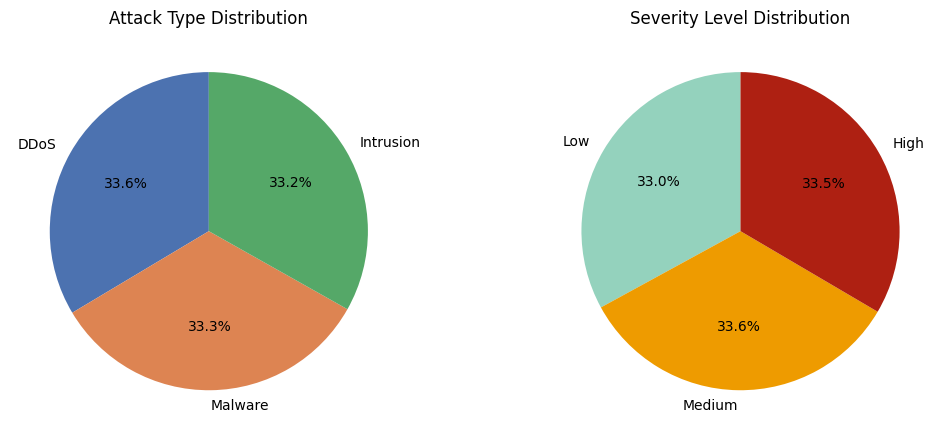

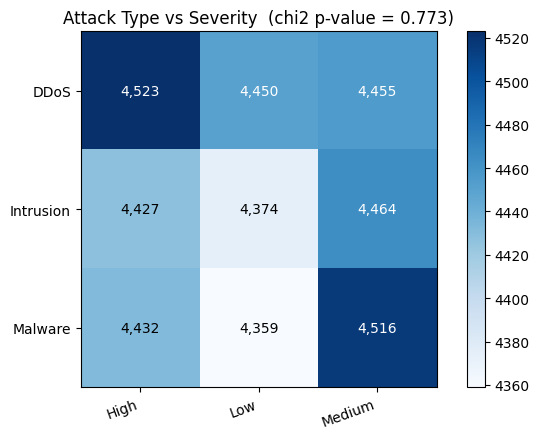

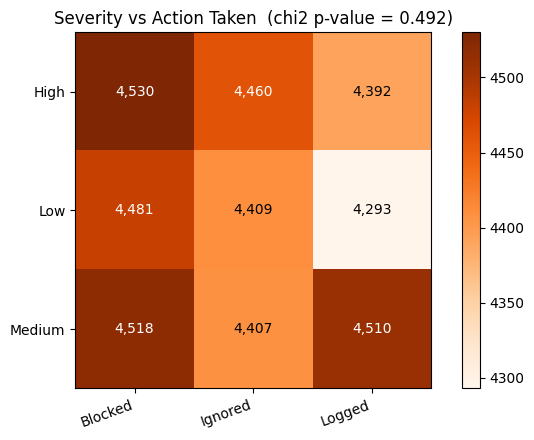

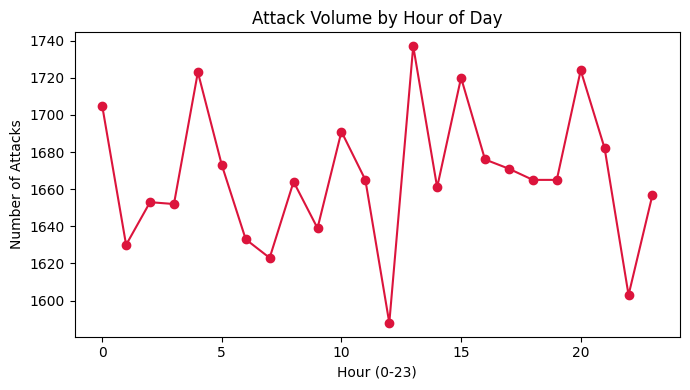

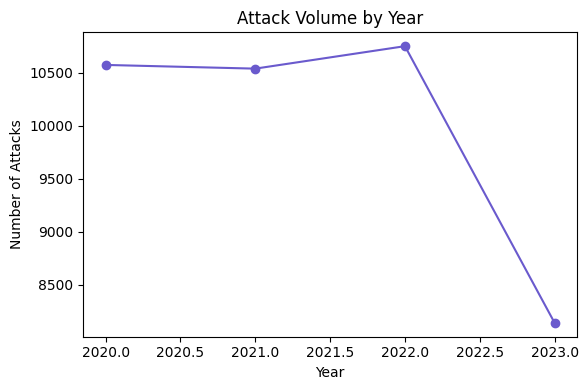

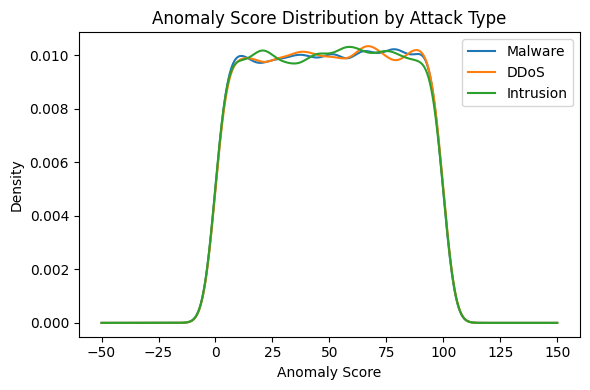

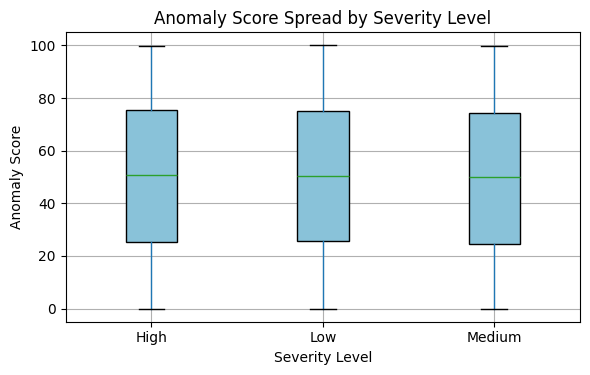

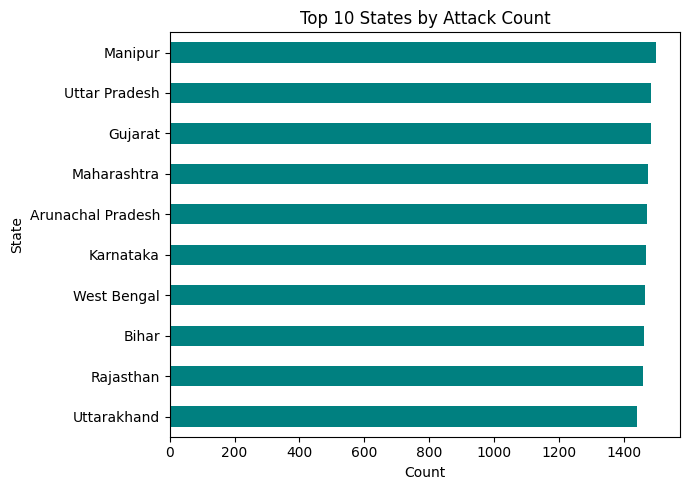

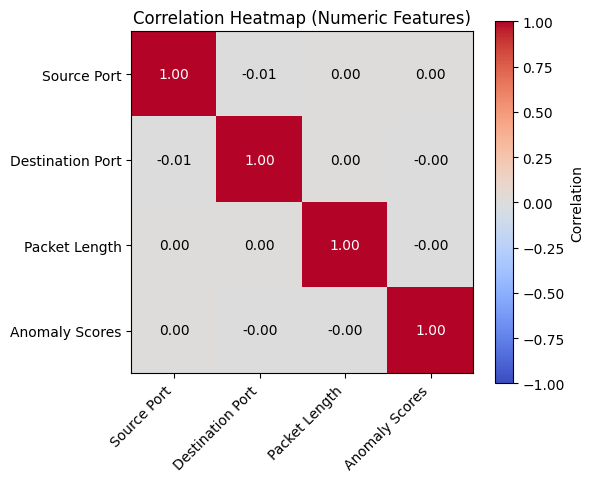

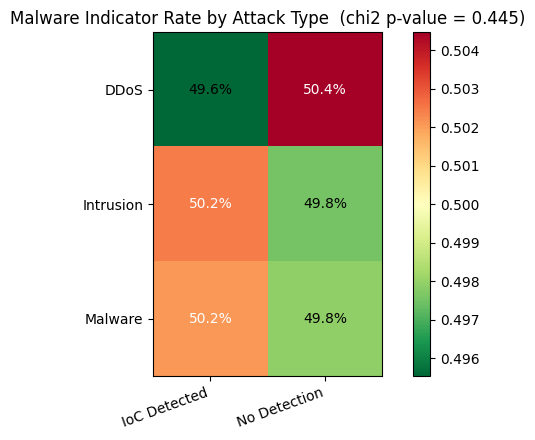

Charts saved to charts

Chi-square p-values -> AttackType/Severity: 0.7730, Severity/Action: 0.4915, AttackType/MalwareIndicator: 0.4453


In [21]:
def annotated_heatmap(ct, title, fname, cmap="Blues", fmt="int"):
    """Crosstab -> heatmap with the value written inside each cell."""
    fig, ax = plt.subplots(figsize=(6.5,4.5))
    im = ax.imshow(ct.values, cmap=cmap)
    ax.set_xticks(range(len(ct.columns))); ax.set_xticklabels(ct.columns, rotation=20, ha="right")
    ax.set_yticks(range(len(ct.index))); ax.set_yticklabels(ct.index)

    vmin, vmax = ct.values.min(), ct.values.max()
    value_range = vmax - vmin if vmax > vmin else 1  # avoid divide-by-zero when every cell is equal

    for i in range(ct.shape[0]):
        for j in range(ct.shape[1]):
            val = ct.values[i, j]
            label = f"{val*100:.1f}%" if fmt == "pct" else f"{val:,}"
            normalized = (val - vmin) / value_range   # 0-1, matches how imshow actually colored this cell
            color = "white" if normalized > 0.5 else "black"
            ax.text(j, i, label, ha="center", va="center", color=color)
    plt.colorbar(im, ax=ax)
    plt.title(title)
    plt.tight_layout(); plt.savefig(fname); plt.show()


def exploratory_analysis(df, out_dir="charts"):
    # 1. Distribution overview: Attack Type & Severity as side-by-side pie charts
    fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
    df["Attack Type"].value_counts().plot(
        kind="pie", autopct="%1.1f%%", ax=axes[0],
        colors=["#4C72B0","#DD8452","#55A868"], startangle=90)
    axes[0].set_ylabel(""); axes[0].set_title("Attack Type Distribution")
    df["Severity Level"].value_counts().reindex(["Low","Medium","High"]).plot(
        kind="pie", autopct="%1.1f%%", ax=axes[1],
        colors=["#94D2BD","#EE9B00","#AE2012"], startangle=90)
    axes[1].set_ylabel(""); axes[1].set_title("Severity Level Distribution")
    plt.tight_layout(); plt.savefig(f"{out_dir}/distribution_overview.png"); plt.show()

    # 2. Attack Type vs Severity -- annotated heatmap + chi-square test
    ct1 = pd.crosstab(df["Attack Type"], df["Severity Level"])
    chi2_1, p1, _, _ = chi2_contingency(ct1)
    annotated_heatmap(ct1, f"Attack Type vs Severity  (chi2 p-value = {p1:.3f})",
                       f"{out_dir}/attacktype_vs_severity_heatmap.png", cmap="Blues")

    # 3. Severity vs Action Taken -- annotated heatmap + chi-square test
    ct2 = pd.crosstab(df["Severity Level"], df["Action Taken"])
    chi2_2, p2, _, _ = chi2_contingency(ct2)
    annotated_heatmap(ct2, f"Severity vs Action Taken  (chi2 p-value = {p2:.3f})",
                       f"{out_dir}/severity_vs_action_heatmap.png", cmap="Oranges")

    # 4. Attack volume by hour of day (line)
    plt.figure(figsize=(7,4))
    df["Hour"].value_counts().sort_index().plot(kind="line", marker="o", color="crimson")
    plt.title("Attack Volume by Hour of Day"); plt.xlabel("Hour (0-23)"); plt.ylabel("Number of Attacks")
    plt.tight_layout(); plt.savefig(f"{out_dir}/attacks_by_hour.png"); plt.show()

    # 5. Attack volume by year (line trend)
    plt.figure(figsize=(6,4))
    df["Year"].value_counts().sort_index().plot(kind="line", marker="o", color="slateblue")
    plt.title("Attack Volume by Year"); plt.ylabel("Number of Attacks")
    plt.tight_layout(); plt.savefig(f"{out_dir}/attacks_by_year.png"); plt.show()

    # 6. Anomaly score distribution by attack type (KDE)
    plt.figure(figsize=(6,4))
    for atype in df["Attack Type"].unique():
        df[df["Attack Type"] == atype]["Anomaly Scores"].plot(kind="kde", label=atype)
    plt.title("Anomaly Score Distribution by Attack Type")
    plt.xlabel("Anomaly Score"); plt.legend()
    plt.tight_layout(); plt.savefig(f"{out_dir}/anomaly_score_by_attacktype.png"); plt.show()

    # 7. Anomaly score spread by severity (boxplot)
    plt.figure(figsize=(6,4))
    df.boxplot(column="Anomaly Scores", by="Severity Level",
               ax=plt.gca(), patch_artist=True,
               boxprops=dict(facecolor="#89C2D9"))
    plt.title("Anomaly Score Spread by Severity Level"); plt.suptitle("")
    plt.xlabel("Severity Level"); plt.ylabel("Anomaly Score")
    plt.tight_layout(); plt.savefig(f"{out_dir}/anomaly_score_boxplot_by_severity.png"); plt.show()

    # 8. Top 10 states by attack count (a ranking question genuinely fits a bar chart)
    plt.figure(figsize=(7,5))
    df["State"].value_counts().head(10).plot(kind="barh", color="teal")
    plt.title("Top 10 States by Attack Count"); plt.xlabel("Count")
    plt.gca().invert_yaxis()
    plt.tight_layout(); plt.savefig(f"{out_dir}/top_states.png"); plt.show()

    # 9. Correlation heatmap (numeric features) -- now with values annotated in each cell
    fig, ax = plt.subplots(figsize=(6,5))
    num_cols = ["Source Port","Destination Port","Packet Length","Anomaly Scores"]
    corr = df[num_cols].corr()
    im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax, label="Correlation")
    ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=45, ha="right")
    ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols)

    # corr values are always between -1 and 1 (fixed vmin/vmax above), so the
    # normalized position is just (val - (-1)) / (1 - (-1)) = (val + 1) / 2
    for i in range(len(num_cols)):
        for j in range(len(num_cols)):
            val = corr.iloc[i, j]
            normalized = (val + 1) / 2
            color = "white" if normalized > 0.75 or normalized < 0.25 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color)

    ax.set_title("Correlation Heatmap (Numeric Features)")
    plt.tight_layout(); plt.savefig(f"{out_dir}/correlation_heatmap.png"); plt.show()

    # 10. Malware Indicator rate by Attack Type -- annotated proportion heatmap
    ct3_counts = pd.crosstab(df["Attack Type"], df["Malware Indicators"])
    chi2_3, p3, _, _ = chi2_contingency(ct3_counts)
    ct3_pct = ct3_counts.div(ct3_counts.sum(axis=1), axis=0).fillna(0)
    annotated_heatmap(ct3_pct, f"Malware Indicator Rate by Attack Type  (chi2 p-value = {p3:.3f})",
                       f"{out_dir}/malware_indicator_heatmap.png", cmap="RdYlGn_r", fmt="pct")

    print("Charts saved to", out_dir)
    print(f"\nChi-square p-values -> AttackType/Severity: {p1:.4f}, "
          f"Severity/Action: {p2:.4f}, AttackType/MalwareIndicator: {p3:.4f}")
    return {"p_attacktype_severity": p1, "p_severity_action": p2, "p_attacktype_malware": p3}

results = exploratory_analysis(df_clean)

Shape: (40000, 25)
             Timestamp Source IP Address Destination IP Address  Source Port  \
0  2023-05-30 06:33:58     103.216.15.12           84.9.164.252        31225   
1  2020-08-26 07:08:30    78.199.217.198         66.191.137.154        17245   
2  2022-11-13 08:23:25      63.79.210.48          198.219.82.17        16811   
3  2023-07-02 10:38:46     163.42.196.10        101.228.192.255        20018   
4  2023-07-16 13:11:07     71.166.185.76        189.243.174.238         6131   

   Destination Port Protocol  Packet Length Packet Type Traffic Type  \
0             17616     ICMP            503        Data         HTTP   
1             48166     ICMP           1174        Data         HTTP   
2             53600      UDP            306     Control         HTTP   
3             32534      UDP            385        Data         HTTP   
4             26646      TCP           1462        Data          DNS   

                                        Payload Data  ... Action Ta

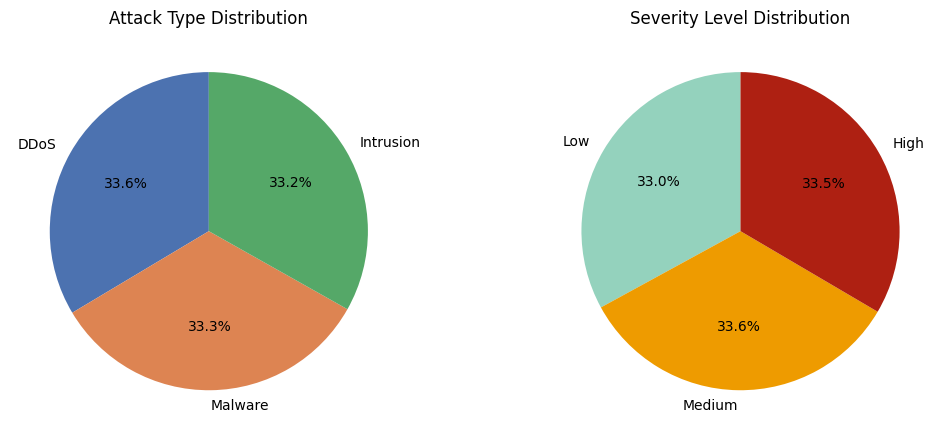

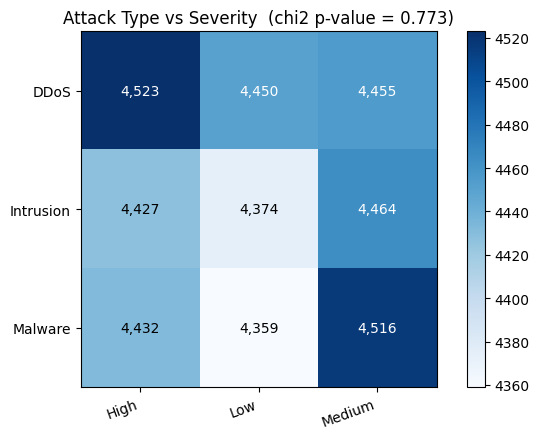

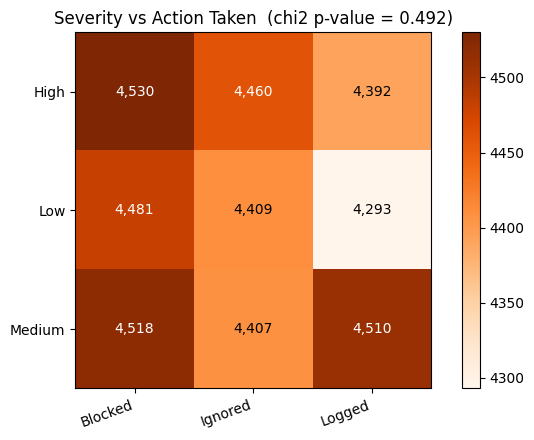

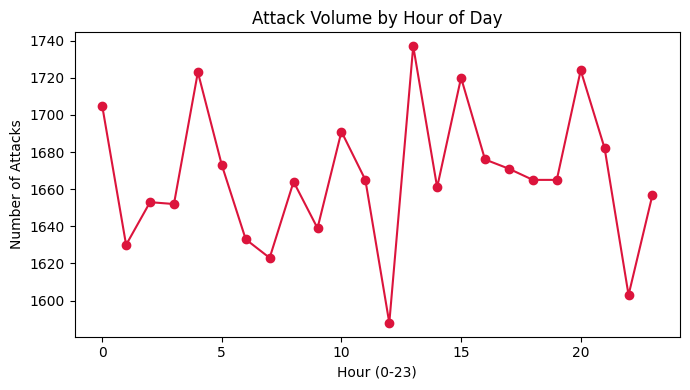

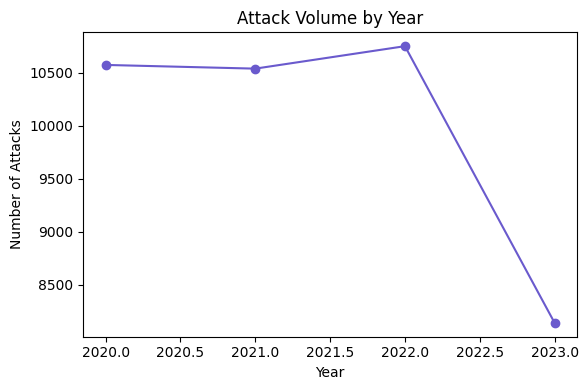

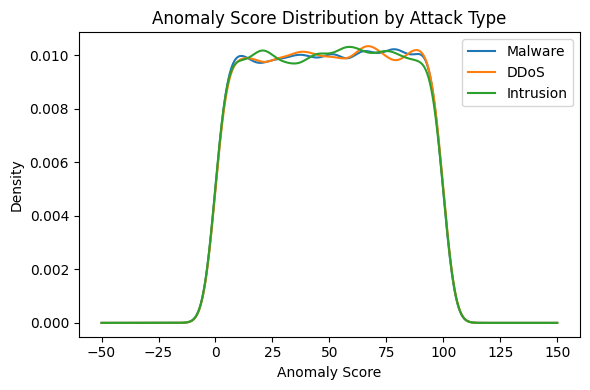

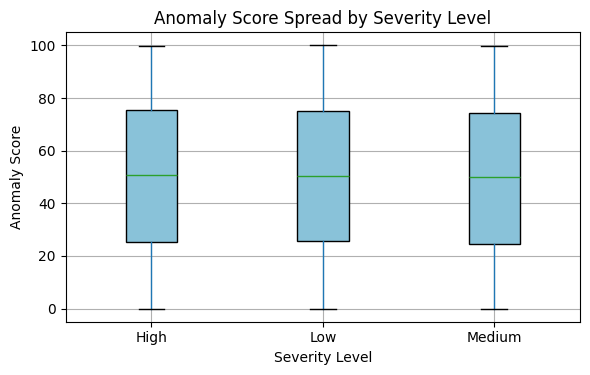

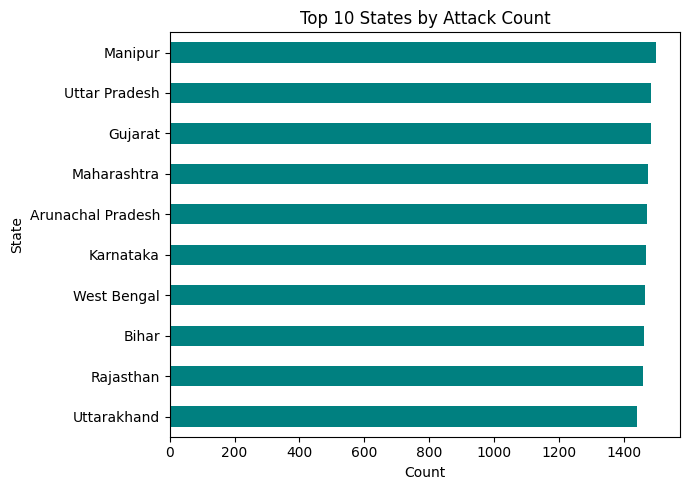

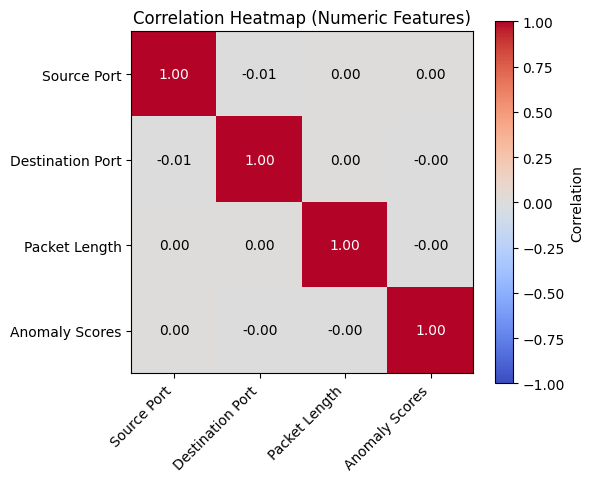

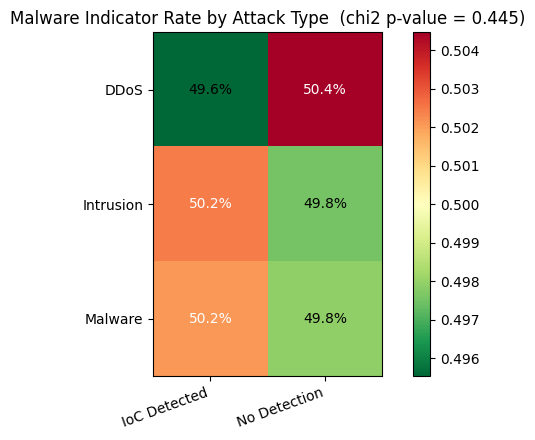

Charts saved to charts

Chi-square p-values -> AttackType/Severity: 0.7730, Severity/Action: 0.4915, AttackType/MalwareIndicator: 0.4453

Pipeline complete. Cleaned data saved to cybersecurity_attacks_cleaned.csv


(                Timestamp  Source Port  Destination Port Protocol  \
 0     2023-05-30 06:33:58        31225             17616     ICMP   
 1     2020-08-26 07:08:30        17245             48166     ICMP   
 2     2022-11-13 08:23:25        16811             53600      UDP   
 3     2023-07-02 10:38:46        20018             32534      UDP   
 4     2023-07-16 13:11:07         6131             26646      TCP   
 ...                   ...          ...               ...      ...   
 39995 2023-05-26 14:08:42        31005              6764      UDP   
 39996 2023-03-27 00:38:27         2553             28091      UDP   
 39997 2022-03-31 01:45:49        22505             25152      UDP   
 39998 2023-09-22 18:32:38        20013              2703      UDP   
 39999 2023-10-10 11:59:52        50137             55575     ICMP   
 
        Packet Length Packet Type Traffic Type Malware Indicators  \
 0                503        Data         HTTP       IoC Detected   
 1               117

In [22]:
def run_pipeline():
    df = load_data()
    df_clean = clean_data(df)
    stats = summary_statistics(df_clean)
    results = exploratory_analysis(df_clean)
    df_clean.to_csv("cybersecurity_attacks_cleaned.csv", index=False)
    print("\nPipeline complete. Cleaned data saved to cybersecurity_attacks_cleaned.csv")
    return df_clean, stats, results

run_pipeline()